In [5]:
# =========================================================
# Logistic Regression을 위한 변수 선택
#
# target
# churn : 고객 이탈 여부 (1 = 이탈, 0 = 유지)
#
# features
# 카드 사용 행동을 나타내는 변수들
# =========================================================

features = [
    "transaction_count",
    "transaction_amount",
    "credit_limit",
    "utilization_ratio",
    "inactive_months",
    "count_change",
    "contact_count"
]

X = data[features]
y = data["churn"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (10127, 7)
Target shape: (10127,)


In [6]:
# =========================================================
# 학습 데이터 / 테스트 데이터 분할
#
# train : 모델 학습
# test  : 모델 성능 평가
# =========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (8101, 7)
Test size: (2026, 7)


In [7]:
# =========================================================
# Logistic Regression은 변수 스케일 영향을 받음
# 따라서 StandardScaler로 표준화 진행
# =========================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# =========================================================
# Logistic Regression 모델 학습
#
# 목적
# 고객 이탈 확률을 예측하는 모델 생성
# =========================================================

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [9]:
# =========================================================
# 모델 성능 평가
# =========================================================

from sklearn.metrics import accuracy_score

pred = log_model.predict(X_test_scaled)

acc = accuracy_score(y_test, pred)

print("Logistic Regression Accuracy:", acc)

Logistic Regression Accuracy: 0.8761105626850938


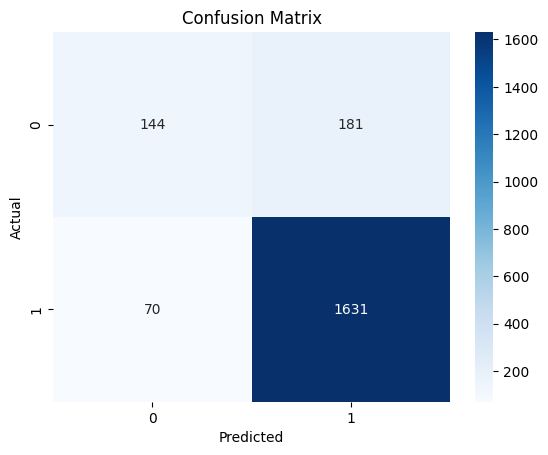

In [13]:
# =========================================================
# Confusion Matrix
#
# 실제 churn / 예측 churn 비교
# =========================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [11]:
# =========================================================
# Logistic Regression 계수 확인
#
# 계수 해석
# +
# 값이 클수록 churn 확률 증가
#
# -
# 값이 작을수록 churn 확률 감소
# =========================================================

coef = pd.DataFrame({
    "feature": features,
    "coef": log_model.coef_[0]
})

coef = coef.sort_values("coef", ascending=False)

coef

,feature,coef
0,transaction_count,2.379003
5,count_change,0.794433
3,utilization_ratio,0.708757
2,credit_limit,0.386894
6,contact_count,-0.505902
4,inactive_months,-0.508965
1,transaction_amount,-1.557202


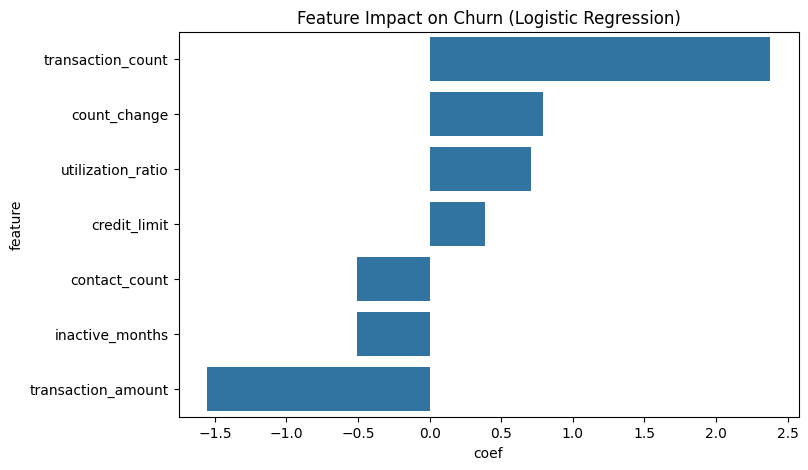

In [12]:
# =========================================================
# 변수 영향 시각화
# =========================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=coef,
    x="coef",
    y="feature"
)

plt.title("Feature Impact on Churn (Logistic Regression)")
plt.show()

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("preprocessed_BankChurners.csv")

X = df.drop(columns=["churn"])
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(" " * 11 + "Train / Test Split Summary")
print("=" * 50)
print(f"X_train shape : {X_train.shape}")
print(f"X_test  shape : {X_test.shape}")
print("-" * 50)
print(f"y_train shape : {y_train.shape}")
print(f"y_test  shape : {y_test.shape}")
print("-" * 50)

print("Target Distribution (Train)")
print(y_train.value_counts().sort_index(ascending=False))
print("-" * 50)

print("Target Distribution (Test)")
print(y_test.value_counts().sort_index(ascending=False))
print("-" * 50)

print("Train Ratio")
print(y_train.value_counts(normalize=True).sort_index(ascending=False))
print("-" * 50)

print("Test Ratio")
print(y_test.value_counts(normalize=True).sort_index(ascending=False))
print("=" * 50)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

           Train / Test Split Summary
X_train shape : (8101, 19)
X_test  shape : (2026, 19)
--------------------------------------------------
y_train shape : (8101,)
y_test  shape : (2026,)
--------------------------------------------------
Target Distribution (Train)
churn
1    6799
0    1302
Name: count, dtype: int64
--------------------------------------------------
Target Distribution (Test)
churn
1    1701
0     325
Name: count, dtype: int64
--------------------------------------------------
Train Ratio
churn
1    0.839279
0    0.160721
Name: proportion, dtype: float64
--------------------------------------------------
Test Ratio
churn
1    0.839585
0    0.160415
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0       0.75      0.55      0.64       325
           1       0.92      0.96      0.94      1701

    accuracy                           0.90      2026
   macro avg       0.83      0.76      0.79      2026
weighted avg     

c:\Users\Playdata\AppData\Local\miniconda3\envs\aistudy_env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


모델명: Logistic Regression
Accuracy : 0.8761
F1-score : 0.9286
Recall   : 0.9588
ROC-AUC  : 0.8926
PR-AUC   : 0.9764

Classification Report
              precision    recall  f1-score   support

           0     0.6729    0.4431    0.5343       325
           1     0.9001    0.9588    0.9286      1701

    accuracy                         0.8761      2026
   macro avg     0.7865    0.7010    0.7314      2026
weighted avg     0.8637    0.8761    0.8653      2026


Confusion Matrix
[[ 144  181]
 [  70 1631]]


,Model,Accuracy,F1-score,Recall,ROC-AUC,PR-AUC
0,Logistic Regression,0.8761,0.9286,0.9588,0.8926,0.9764
